In [1]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
def load_datasets(path):
    dataset = QSPRDataset.fromTableFile(
    filename=path,
    store_dir="dataset_outputs/A2AR/data",
    name="A2ARDataset",
    target_props=[{"name": "Y", "task": "SINGLECLASS", "th": [0.5]}],
    random_state=42,
    smiles_col = 'Drug',
    sep=','
    )
    dataset.prepareDataset(
    feature_calculators=[MorganFP(radius=2, nBits=1024)],
    recalculate_features=True,
    shuffle=False
    )
    from qsprpred.data.descriptors.sets import RDKitDescs
    
    rdkit_descs = RDKitDescs()
    
    dataset.addDescriptors([rdkit_descs])
    
    dataset.descriptorSets
    return dataset
    

In [3]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizerFast, RobertaForMaskedLM, DataCollatorWithPadding
from sklearn.base import BaseEstimator, TransformerMixin

class SMILESDataset(Dataset):
    def __init__(self, smiles, tokenizer, max_len=128):
        self.smiles = smiles
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smile = self.smiles[idx]
        encoding = self.tokenizer(smile, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return encoding


class ChemBERTaTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, model_name="entropy/roberta_zinc_480m", max_len=128, batch_size=32, device=None):
        self.model_name = model_name
        self.max_len = max_len
        self.batch_size = batch_size
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = RobertaForMaskedLM.from_pretrained(self.model_name).to(self.device)
        self.tokenizer = RobertaTokenizerFast.from_pretrained(self.model_name, max_len=self.max_len)
        self.collator = DataCollatorWithPadding(self.tokenizer, padding=True, return_tensors='pt')
        self.embedding_dim = None  # bude nastaven po fit()

    def fit(self, X, y=None):
        # Zjistíme embedding dimenzi na prvním SMILES
        smiles_dataset = SMILESDataset(X, self.tokenizer, max_len=self.max_len)
        dataloader = DataLoader(smiles_dataset, batch_size=1, collate_fn=self.collator)
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].squeeze(1).to(self.device)
                attention_mask = batch['attention_mask'].squeeze(1).to(self.device)
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
                embedding = outputs[1][-1]  # poslední hidden state
                self.embedding_dim = embedding.shape[-1]
                break
        return self

    def transform(self, X):
        self.model.eval()
        smiles_dataset = SMILESDataset(X, self.tokenizer, max_len=self.max_len)
        dataloader = DataLoader(smiles_dataset, batch_size=self.batch_size, collate_fn=self.collator)
        embeddings_list = []

        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].squeeze(1).to(self.device)
                attention_mask = batch['attention_mask'].squeeze(1).to(self.device)
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
                full_embeddings = outputs[1][-1]
                embeddings = ((full_embeddings * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(-1).unsqueeze(-1))
                embeddings_list.append(embeddings)

        all_embeddings = torch.cat(embeddings_list, dim=0).cpu().numpy()
        column_names = [f"chemberta_{i}" for i in range(self.embedding_dim)]
        return pd.DataFrame(all_embeddings, columns=column_names)


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X1_all = load_datasets("A2AR/data/a2ar_train_1")

X2_all = load_datasets("A2AR/data/a2ar_val_1")

X3_all = load_datasets("A2AR/data/a2ar_test_1")

C#CCn1c(=O)c2c(nc3n2CCCN3Cc2ccccc2)n(C)c1=O


/tmp/ipykernel_20575/2503285271.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(X1_all.df['Drug'][100])
/tmp/ipykernel_20575/2503285271.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  MolGraph(X1_all.df['Drug'][100])


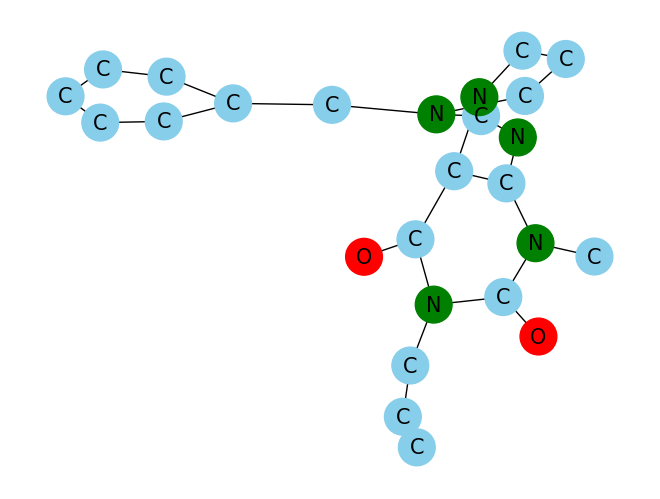

In [5]:
from MolEval.MolGraph import MolGraph
print(X1_all.df['Drug'][100])
MolGraph(X1_all.df['Drug'][100])

In [6]:
from MolEval import MolEmb 
model_name = 'BERT'  # Replace with the model you want to use
openai_api_key = 'your_openai_api_key'  # Required if using GPT
huggingface_token = 'your_huggingface_token'  # Required if using LLaMA2
X1_all.df["SMILES"] = X1_all.df["Drug"]
extractor = MolEmb.EmbeddingExtractor(model_name=model_name, df=X1_all.df)
emb, df = extractor.get_embeddings()
print(emb)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


           0         1         2         3         4         5         6    \
0    -0.112488  0.217459  0.640002 -0.139795  0.448580 -0.431056 -0.097757   
1    -0.134230  0.244658  0.899453 -0.084805  0.369488 -0.414859 -0.157873   
2    -0.271912  0.232590  0.514945 -0.220345  0.532959 -0.414607 -0.056152   
3    -0.027852  0.272938  0.678768 -0.138597  0.421922 -0.465832 -0.281631   
4    -0.238780  0.186597  0.667444 -0.200046  0.395746 -0.285010 -0.029998   
...        ...       ...       ...       ...       ...       ...       ...   
2402 -0.055485  0.167087  0.687167 -0.230739  0.381839 -0.308785  0.027583   
2403  0.001345  0.182162  0.677243 -0.257160  0.408254 -0.377854 -0.012216   
2404  0.048741  0.070641  0.625531 -0.160977  0.466797 -0.317218 -0.195760   
2405 -0.066074 -0.014473  0.604552 -0.286128  0.420881 -0.289199 -0.150150   
2406 -0.075729  0.161981  0.479871 -0.158638  0.479553 -0.371834 -0.138248   

           7         8         9    ...       758       759    

In [7]:
X2_all.df["SMILES"] = X2_all.df["Drug"]
extractor2 = MolEmb.EmbeddingExtractor(model_name=model_name, df=X2_all.df)
emb2, df2 = extractor2.get_embeddings()

In [8]:
display(emb)

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.112488,0.217459,0.640002,-0.139795,0.448580,-0.431056,-0.097757,-0.030655,-0.209472,0.331316,...,0.078527,0.086105,-0.094875,-0.472496,-0.103672,-0.423487,-0.181016,-0.305212,0.081285,0.398699
1,-0.134230,0.244658,0.899453,-0.084805,0.369488,-0.414859,-0.157873,0.166199,-0.240730,0.396311,...,0.088856,0.129892,-0.141134,-0.588760,0.038978,-0.450941,-0.255994,-0.269519,0.127911,0.385169
2,-0.271912,0.232590,0.514945,-0.220345,0.532959,-0.414607,-0.056152,0.109245,-0.253696,0.361701,...,0.137244,0.271778,-0.092310,-0.587366,0.139042,-0.324096,-0.146566,-0.422986,0.007290,0.384023
3,-0.027852,0.272938,0.678768,-0.138597,0.421922,-0.465832,-0.281631,0.183330,-0.371920,0.374653,...,0.109564,0.151087,-0.200127,-0.600006,0.129027,-0.404594,-0.334887,-0.245410,0.038109,0.382947
4,-0.238780,0.186597,0.667444,-0.200046,0.395746,-0.285010,-0.029998,0.008567,-0.236847,0.304388,...,-0.004022,0.119530,-0.061735,-0.453420,-0.171894,-0.323308,-0.165662,-0.337395,0.087438,0.338894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2402,-0.055485,0.167087,0.687167,-0.230739,0.381839,-0.308785,0.027583,0.152423,-0.333503,0.268722,...,0.001259,0.148416,-0.174352,-0.497407,-0.026203,-0.378279,-0.217425,-0.300689,0.134258,0.470808
2403,0.001345,0.182162,0.677243,-0.257160,0.408254,-0.377854,-0.012216,0.059911,-0.189877,0.323128,...,0.108463,0.219005,-0.280415,-0.525542,0.034979,-0.438552,-0.090013,-0.362388,0.143306,0.478415
2404,0.048741,0.070641,0.625531,-0.160977,0.466797,-0.317218,-0.195760,0.192823,-0.250710,0.288374,...,0.004227,0.177774,-0.159768,-0.422275,0.009697,-0.313999,-0.273450,-0.288267,0.110543,0.417492
2405,-0.066074,-0.014473,0.604552,-0.286128,0.420881,-0.289199,-0.150150,0.160510,-0.230978,0.256892,...,-0.128241,0.185407,-0.206186,-0.422552,-0.059346,-0.343750,-0.137431,-0.384423,0.018685,0.383658


In [9]:
display(emb2)

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,0.063889,0.199285,0.670852,-0.253533,0.373827,-0.308091,0.060650,0.085613,-0.282294,0.245172,...,0.020583,0.215380,-0.126283,-0.462431,0.102573,-0.351076,-0.147502,-0.400183,0.058545,0.404210
1,-0.074852,0.104616,0.671260,-0.100800,0.473999,-0.442814,-0.089763,-0.000354,-0.071007,0.310372,...,0.098000,-0.023239,-0.259308,-0.548007,0.025600,-0.467629,-0.270406,-0.282694,0.068261,0.345762
2,-0.114308,0.336750,0.564838,-0.277590,0.380612,-0.337986,-0.170212,0.008074,-0.230728,0.306552,...,0.010147,0.094148,-0.203056,-0.565758,0.064479,-0.225335,-0.137126,-0.362370,-0.033160,0.423507
3,-0.173831,-0.201634,0.352251,-0.402034,0.258393,-0.193758,0.369641,0.097571,-0.189847,0.186260,...,0.060051,0.498994,-0.193254,-0.418340,-0.102397,-0.409948,-0.041518,-0.502878,-0.091855,0.655191
4,-0.066541,0.362477,0.827634,-0.253967,0.333074,-0.367305,-0.185582,0.017935,-0.308822,0.281820,...,0.063838,0.185751,-0.179499,-0.530758,0.011525,-0.384852,-0.236647,-0.180170,0.044268,0.334787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,-0.234911,0.142714,0.726620,-0.200302,0.380032,-0.284497,-0.056787,0.101079,-0.326232,0.265677,...,-0.006450,0.101472,-0.132303,-0.572008,-0.038378,-0.422587,-0.222789,-0.417184,0.093426,0.284957
807,0.036833,0.130696,0.862690,-0.240435,0.353979,-0.438200,-0.142936,0.060664,-0.157354,0.356167,...,0.219633,0.109137,-0.251207,-0.538059,-0.039279,-0.240629,-0.324043,-0.149457,0.019127,0.434172
808,-0.008084,0.306882,0.942660,-0.248695,0.377824,-0.412381,-0.105610,-0.059010,-0.147952,0.393502,...,0.159214,0.125223,-0.284130,-0.580458,0.047648,-0.375121,-0.237141,-0.230092,0.141120,0.351224
809,0.102431,0.191657,0.801105,-0.222311,0.426580,-0.388195,-0.157729,0.186180,-0.165625,0.403789,...,-0.003947,0.162246,-0.263325,-0.415198,-0.014297,-0.297842,-0.195883,-0.329013,0.130685,0.395917


In [10]:
X3_all.df["SMILES"] = X3_all.df["Drug"]
extractor3 = MolEmb.EmbeddingExtractor(model_name=model_name, df=X3_all.df)
emb3, df3 = extractor3.get_embeddings()
display(emb3)

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,0.304046,0.005102,0.588011,-0.195826,0.441418,-0.357118,0.029041,0.003665,-0.140670,0.260039,...,0.160846,0.193405,-0.316659,-0.348962,-0.017484,-0.118381,-0.033775,-0.311065,-0.012910,0.492836
1,-0.079287,0.116902,0.494223,-0.263274,0.291704,-0.491442,0.103230,0.269528,-0.295051,0.256210,...,-0.008698,0.157504,-0.239317,-0.659093,0.007149,-0.462525,-0.300047,-0.333854,-0.043041,0.426994
2,-0.056121,0.053159,0.394378,-0.121967,0.295974,-0.358178,-0.173586,0.229938,-0.107178,0.204864,...,-0.005986,0.268912,-0.233658,-0.429575,-0.046874,-0.303174,-0.283352,-0.293084,0.050716,0.329137
3,-0.045066,0.250476,0.579952,-0.252373,0.265131,-0.430994,-0.012458,0.167612,-0.232637,0.274451,...,-0.083939,0.229752,-0.214493,-0.583817,0.056239,-0.427392,-0.205100,-0.367931,0.077503,0.265500
4,0.057807,0.054190,0.513919,-0.152553,0.277455,-0.447353,-0.153759,0.288113,-0.205073,0.251452,...,-0.002516,0.187215,-0.153977,-0.498097,0.029908,-0.402465,-0.200308,-0.510007,-0.094979,0.488847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,-0.040041,0.179281,0.677749,-0.146238,0.370211,-0.300070,-0.087291,-0.112971,-0.137273,0.313694,...,0.121041,0.098994,-0.115169,-0.482579,-0.046486,-0.332702,-0.195202,-0.365071,0.006094,0.468558
860,0.027893,0.149647,0.714054,-0.104511,0.393549,-0.448409,-0.220211,0.167916,-0.232183,0.310536,...,0.029896,0.122384,-0.124865,-0.465668,-0.006452,-0.397507,-0.280685,-0.438121,-0.000584,0.454543
861,0.039922,0.077324,0.779401,-0.162596,0.494215,-0.333333,-0.017818,-0.086698,-0.163930,0.259452,...,0.059832,0.042442,-0.251019,-0.463576,-0.097133,-0.417005,-0.241711,-0.260283,0.093836,0.374664
862,-0.071196,0.240405,0.600467,-0.237427,0.238088,-0.424542,-0.035642,0.162220,-0.224954,0.271950,...,-0.063250,0.253789,-0.240786,-0.588117,0.070041,-0.440411,-0.179697,-0.356942,0.059374,0.274469


In [11]:
transformer = ChemBERTaTransformer()
X_train_emb = transformer.fit_transform(X1_all.df["Drug"])
X_val_emb = transformer.transform(X2_all.df["Drug"])
X_test_emb = transformer.transform(X3_all.df["Drug"])

/tmp/ipykernel_20575/195630644.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  smile = self.smiles[idx]


In [12]:
import pandas as pd
X1_all.X = X1_all.X.reset_index(drop=True)
X_train_emb = X_train_emb.reset_index(drop=True)
X1_all.X = pd.concat([X1_all.X, X_train_emb], axis = 1)

In [13]:
X2_all.X = X2_all.X.reset_index(drop=True)
X_val_emb = X_val_emb.reset_index(drop=True)
X2_all.X = pd.concat([X2_all.X, X_val_emb], axis = 1)
X3_all.X = X3_all.X.reset_index(drop=True)
X_test_emb = X_test_emb.reset_index(drop=True)
X3_all.X = pd.concat([X3_all.X, X_test_emb], axis = 1)

In [14]:
X1 = emb
y1 = X1_all.y
X2 = emb2
y2 = X2_all.y
X3 = emb3
y3 = X3_all.y

In [15]:
imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [16]:
pd.DataFrame(X1).columns[pd.DataFrame(X1).isna().any()].tolist()



[]

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))


,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.733360,0.661706,-0.210428,1.113213,0.803821,-0.827522,0.000345,-1.269195,0.484364,0.503929,...,0.415191,-0.910508,1.584370,0.488069,-1.667142,-0.738383,0.072829,0.014238,0.285669,-0.115895
1,-1.012548,0.925747,1.640933,1.945456,-0.218893,-0.611226,-0.647094,0.535252,0.058449,1.341564,...,0.530424,-0.414069,0.974943,-1.266414,0.338916,-1.077725,-0.783471,0.414408,0.887030,-0.255559
2,-2.780540,0.808590,-1.102794,-0.105868,1.894903,-0.607858,0.448417,0.013180,-0.118218,0.895516,...,1.070248,1.194541,1.618161,-1.245379,1.746091,0.490127,0.466282,-1.306178,-0.668677,-0.267386
3,0.353464,1.200279,0.066192,1.131337,0.459114,-1.291943,-1.979948,0.692277,-1.729104,1.062438,...,0.761449,-0.173777,0.197753,-1.436116,1.605252,-0.504860,-1.684477,0.684700,-0.271186,-0.278495
4,-2.355088,0.362111,-0.014610,0.201334,0.120641,1.122871,0.730085,-0.909667,0.111365,0.156889,...,-0.505732,-0.531546,2.020971,0.775932,-2.626533,0.499869,0.248183,-0.346580,0.365031,-0.733207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3470,1.433925,1.587484,-1.395356,0.840935,-0.942056,0.680400,-2.215135,0.737718,0.012090,-0.654001,...,1.918445,-1.248301,0.538595,0.861373,1.971445,1.353691,-0.746016,-0.888279,-3.303487,0.175495
3471,-2.403431,-0.974819,-1.241655,-1.522126,1.400333,1.375408,-0.755397,1.976026,-0.061012,-1.537797,...,-0.908216,-0.437455,1.165921,-1.203451,0.976636,-0.156055,-0.297124,0.296783,1.659204,-1.676904
3472,-0.588030,0.574300,0.787124,0.836343,0.313862,-1.032399,-0.680173,-0.638804,-0.859164,2.110556,...,0.976260,-0.453749,-0.126477,-1.495374,0.385919,-1.518004,-1.339782,0.921138,0.179449,-0.210183
3473,-2.864255,0.098195,0.724515,0.175494,1.224491,0.752689,-0.042560,-0.711095,-1.834428,1.011329,...,-0.880272,-0.713461,0.611645,-0.977688,-2.345273,-0.719047,-1.120501,1.040807,1.979256,-2.010826


In [18]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [19]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, matthews_corrcoef
import pandas as pd

def test_fun(dic,  X_train, y_train, X_test, y_test) -> pd.DataFrame:
    param_grid_t = ParameterGrid(dic)
    i = 0
    val_f1_t = []
    val_acc_t = []
    val_mcc_t = []
    param_len_t = len(param_grid_t)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device used:", device)
    for param in param_grid_t:
        i += 1
        print(i, '/', param_len_t)
        model_sts_t = STFullyConnected(n_dim=X_train.shape[1],  # počet vstupních neuronů (počet deskriptorů)
        n_class=1,  # regresní úloha (1 výstup)
        gpus=[],
        device=device,
        is_reg=False, **param)
        model_sts_t.fit(X_train, y_train)
        res = model_sts_t.predict(X_test)
        res = res >0.5
        val_f1_t.append(f1_score(res, y_test))
        val_acc_t.append(accuracy_score(res, y_test))
        val_mcc_t.append(matthews_corrcoef(res, y_test))
        print(param)
        print(f1_score(res, y_test))
        print(accuracy_score(res, y_test))
        print(matthews_corrcoef(res, y_test))
    my_df = pd.DataFrame(param_grid_t)
    my_df["F1"] = val_f1_t
    my_df["Acc"] = val_acc_t
    my_df["MCC"] = val_mcc_t
    return my_df

In [20]:
import optuna
from sklearn.metrics import f1_score, accuracy_score, matthews_corrcoef
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
def objective(trial, X_train, y_train, X_test, y_test):
    dropout_frac = trial.suggest_categorical("dropout_frac", [0, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9])
    patience = trial.suggest_categorical("patience", [10, 40, 75])
    tol = trial.suggest_categorical("tol", [1e-5, 1e-4, 1e-3, 1e-2, 0])
    weight_decay = trial.suggest_categorical("weight_decay", [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 0])
    n_epochs = trial.suggest_categorical("n_epochs", [200, 300, 500, 1000])
    batch_size = trial.suggest_categorical("batch_size", [1024, 512, 256, 128, 64])
    optimizer = trial.suggest_categorical("optimizer", ["optim.AdamW", "optim.RMSprop"])
    lr = trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6])
    neuron_layers_dict = {
    '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
    '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]': [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
    '[4096, 1024, 256, 64, 8]': [4096, 1024, 256, 64, 8],
    '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]': [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
    '[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]': [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
    '[200]': [200],
    '[2000]': [2000],
    '[2000, 1000]': [2000, 1000],
    '[2000, 1000, 500]': [2000, 1000, 500],
    '[1000, 50]': [1000, 50],
    '[4000, 2000]': [4000, 2000],
    '[4000, 2000, 1000, 500]': [4000, 2000, 1000, 500],
    '[4000, 2000, 2000, 500]': [4000, 2000, 2000, 500]
    }
    neuron_layers_size = trial.suggest_categorical("neuron_layers_size", list(neuron_layers_dict.keys()))
    opt = {"optim.AdamW": optim.AdamW,
           "optim.RMSprop": optim.RMSprop}
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(device)
    
    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        gpus=[],
        device=device,
        is_reg=False,
        act_fun=F.selu,
        dropout_frac=dropout_frac,
        patience=patience,
        tol=tol,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=weight_decay,
        n_epochs=n_epochs,
        neuron_layers= neuron_layers_dict[neuron_layers_size],  # Použití neuron_layers_size
        batch_size=batch_size,
        optimizer=opt[optimizer],
        lr=lr,
        random_seed=69
    )

    # Trénink a predikce
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_test, preds_bin)
    acc = accuracy_score(y_test, preds_bin)
    mcc = matthews_corrcoef(y_test, preds_bin)
    
    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_test, preds_bin))
    return mcc  # maximalizujeme MCC


In [22]:
study_3 = optuna.create_study(
    study_name="A2AR_study_molemb",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study_3.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=200
)
print("Best MCC:", study_3.best_value)
print("Best parameters:", study_3.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study_3.best_trial.user_attrs["f1"])
print("Best ACC:", study_3.best_trial.user_attrs["acc"])

[I 2025-04-27 20:43:40,153] Using an existing study with name 'A2AR_study_molemb' instead of creating a new one.


cuda


array([[ 30,   0],
       [781,   0]])

[I 2025-04-27 20:44:01,981] Trial 393 finished with value: 0.0 and parameters: {'dropout_frac': 0.1, 'patience': 10, 'tol': 1e-05, 'weight_decay': 0.001, 'n_epochs': 200, 'batch_size': 512, 'optimizer': 'optim.RMSprop', 'lr': 1, 'neuron_layers_size': '[200]'}. Best is trial 202 with value: 0.3331662383127306.


cuda


...

array([[ 19,  11],
       [276, 505]])

[I 2025-04-27 20:46:56,698] Trial 395 finished with value: 0.10982864556436388 and parameters: {'dropout_frac': 0.6, 'patience': 75, 'tol': 0.01, 'weight_decay': 0.0001, 'n_epochs': 200, 'batch_size': 256, 'optimizer': 'optim.AdamW', 'lr': 1e-06, 'neuron_layers_size': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 202 with value: 0.3331662383127306.


cuda


[W 2025-04-27 20:53:32,995] Trial 396 failed with parameters: {'dropout_frac': 0.2, 'patience': 75, 'tol': 0.0001, 'weight_decay': 1e-06, 'n_epochs': 1000, 'batch_size': 64, 'optimizer': 'optim.RMSprop', 'lr': 1e-05, 'neuron_layers_size': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_20575/3356300355.py", line 11, in <lambda>
    lambda trial: objective(trial, X1, y1, X2, y2),
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_20575/2225250540.py", line 59, in objective
    model.fit(X_train, y_train)
  File "/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py", line 157, in fit
    monitor.onBatchEnd(i, float(loss))
KeyboardInterrupt

KeyboardInterrupt: 

In [ ]:
print("CUDA_LAUNCH_BLOCKING =", os.environ.get("CUDA_LAUNCH_BLOCKING"))


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
